# Predictions with the random forest parameterization

Example of loading trained Random Forest parameterization and making predictions for a single basin

In [1]:
import time
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.tri import Triangulation
import cmocean

## Load the random forest parameterization

The trained random forest is saved as a scitkit-learn [RandomForestRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html)

In [2]:
# Load the model
regr = np.load('../analysis/mean/rf.pkl', allow_pickle=True)

The model is trained with normalized inputs/outputs, and the ordering of features must match the order from training

In [3]:
# The order of features in the model is important
feature_names = [
        'bed',
        'surface',
        'thickness',
        'grounding_line_distance',
        'basal_melt',
        'potential',
        'surface_slope',
        'bed_slope',
        'potential_slope',
]

# For simplicity hard-coded normalization data
xscale = (np.array([-3.76479507e+03,  2.79544981e-02,  1.00000000e+01,  8.87767746e+01,
       -2.35550277e+00, -1.35971982e+07,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00]), np.array([3.58696063e+03, 4.04517225e+03, 4.57771180e+03, 1.53002848e+06,
       1.19986959e+00, 3.79722119e+07, 7.14976876e-01, 1.05716414e+00,
       9.59959226e+04]))
yscale = (-16.715229, 1228.9762)

# Construct features for the Amundsen Sea basin (G-H)

Here, we load the Amundsen basin feautres. These features are already aggregated into a dictionary for easy reading/writing. But any source will do, as long as the order of features matches the order from training (`feature_names`)

In [4]:
features = np.load('../analysis/features/features_G-H.pkl', allow_pickle=True)
print(features.keys())

dict_keys(['bed', 'surface', 'thickness', 'grounding_line_distance', 'basal_melt', 'potential', 'surface_slope', 'bed_slope', 'potential_slope'])


Put each dictionary feature into the column of an array

In [5]:
N = len(features['bed']) # Number of samples for each features
X = np.zeros((N, len(feature_names)), dtype=np.float32)
for i in range(len(feature_names)):
    X[:,i] = features[feature_names[i]]
np.set_printoptions(precision=2)
print('Physical X feature range:')
print('\tmin:', np.nanmin(X, axis=0))
print('\tmax:', np.nanmax(X, axis=0))

Physical X feature range:
	min: [-2.38e+03  6.57e-02  1.00e+01  8.88e+01 -2.15e+00 -1.36e+07  1.18e-04
  1.33e-03  2.46e+00]
	max: [3.34e+03 3.42e+03 3.97e+03 5.86e+05 2.16e-01 3.35e+07 3.58e-01 3.98e-01
 9.47e+03]


In [6]:
# Normalize X
X = (X - xscale[0])/(xscale[1] - xscale[0])
print('Normalized X feature range:')
print('\tmin:', np.nanmin(X, axis=0))
print('\tmax:', np.nanmax(X, axis=0))

Normalized X feature range:
	min: [ 1.89e-01  9.32e-06  0.00e+00 -2.00e-12  5.83e-02  3.88e-09  1.64e-04
  1.26e-03  2.57e-05]
	max: [0.97 0.84 0.87 0.38 0.72 0.91 0.5  0.38 0.1 ]


## Compute prediction for Amundsen basin
To make the prediction, we can simply use the `.predict()` method from the scikit-learn object

In [7]:
# Make the prediction and time it
t0 = time.perf_counter()
ypred = regr.predict(X)
t1 = time.perf_counter()
dt = t1 - t0
print(f'Predicted {N} values in {dt:.3f}s')

Predicted 28442 values in 0.230s


In [8]:
# Put the prediction back into physical units
ypred = yscale[0] + yscale[1]*ypred
print('Y min/max')
print('\tmin:', np.nanmin(ypred, axis=0))
print('\tmax:', np.nanmax(ypred, axis=0))

Y min/max
	min: 0.12553931962858655
	max: 0.9973856757291664


## Plot the predictions

Plotting will be specific to the grid/mesh that the features are defined on. Here, we have a triangular mesh which is the same as used for ISSM and GlaDS runs.

In [9]:
# Plot the predictions
mesh = np.load('../issm/G-H/data/geom/mesh.npy', allow_pickle=True)
mtri = Triangulation(mesh['x'], mesh['y'], mesh['elements']-1)

# Load ice/ocean levelset. Predictions are only made where ice is
# grounded. Need to zero-pad for plotting
levelset = np.load('../issm/G-H/data/geom/ocean_levelset.npy')
yplot = np.nan*np.zeros(len(levelset), dtype=np.float32)
yplot[levelset>0] = ypred

Text(0, 0.5, 'Northing (m)')

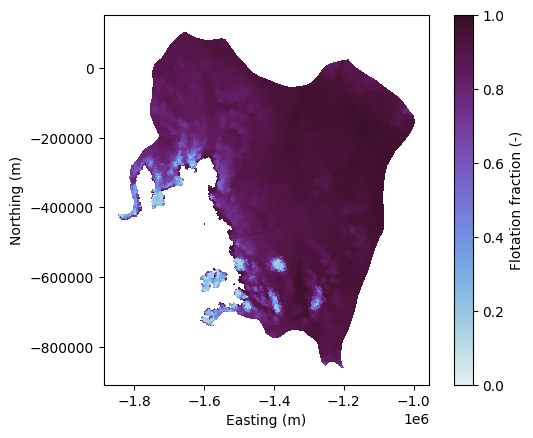

In [10]:
fig,ax = plt.subplots()
fpc = ax.tripcolor(mtri, yplot, vmin=0, vmax=1, cmap=cmocean.cm.dense)
ax.set_aspect('equal')
fig.colorbar(fpc, label='Flotation fraction (-)')
ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')

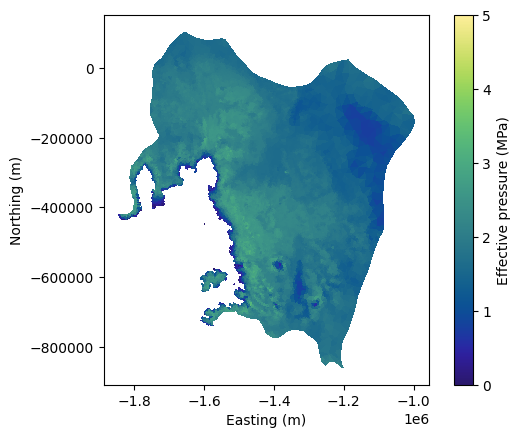

In [11]:
# Transform the predictions into effective pressure
thickness = np.load('../issm/G-H/data/geom/thick.npy')
rhoice = 917
g = 9.81
Nplot = rhoice*g*thickness*(1 - yplot)
fig,ax = plt.subplots()
Npc = ax.tripcolor(mtri, Nplot/1e6, vmin=0, vmax=5, cmap=cmocean.cm.haline)
fig.colorbar(Npc, label='Effective pressure (MPa)')
ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')
ax.set_aspect('equal')